# Customer Churn Prediction using Random Forest
## End-to-End Machine Learning and Deployment Use Case
**Course:** B.Tech – Gen AI (2nd Semester)  
**Dataset:** customer_travel_churn.csv

---
## 1. Introduction

### What is Customer Churn?
Customer churn refers to the phenomenon where customers stop doing business with a company. In the travel industry, churn happens when a loyal customer discontinues using a service — stops booking flights, hotels, or travel packages with a particular provider.

### Why is Churn Prediction Important for Businesses?
Acquiring a new customer typically costs 5–7× more than retaining an existing one. By predicting which customers are likely to churn, travel companies can:
- Launch targeted retention campaigns (discounts, loyalty rewards)
- Personalise service offerings for at-risk customers
- Reduce revenue loss proactively instead of reactively

### Why Random Forest?
Random Forest is an ensemble learning algorithm that builds multiple decision trees on random subsets of data and features, then aggregates their predictions. It is chosen here because:
- It handles a mix of numerical and categorical features naturally
- It is robust to overfitting compared to a single decision tree
- It provides built-in feature importance scores, which are valuable for business insights
- It consistently delivers high accuracy on tabular datasets with minimal hyperparameter tuning

---
## 2. Importing Required Libraries

In [1]:

import pandas as pd
import numpy as np


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import pickle
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 3. Data Loading and Exploration

In [2]:

df = pd.read_csv('customer_travel_churn.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 954 rows × 7 columns


In [3]:

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0


In [4]:

print("Summary Statistics:")
df.describe(include='all')

Summary Statistics:


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
count,954.000000,954,954,954.000000,954,954,954.000000
unique,NaN,3,3,NaN,2,2,NaN
top,NaN,No,Middle Income,NaN,No,No,NaN
freq,NaN,608,409,NaN,594,576,NaN
mean,32.109015,NaN,NaN,2.437107,NaN,NaN,0.234801
std,3.337388,NaN,NaN,1.606233,NaN,NaN,0.424097
min,27.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
25%,30.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
50%,31.000000,NaN,NaN,2.000000,NaN,NaN,0.000000
75%,35.000000,NaN,NaN,4.000000,NaN,NaN,0.000000


In [5]:

print("Missing Values per Column:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nUnique values per categorical column:")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col}: {df[col].unique()}")

Missing Values per Column:
Age                           0
FrequentFlyer                 0
AnnualIncomeClass             0
ServicesOpted                 0
AccountSyncedToSocialMedia    0
BookedHotelOrNot              0
Target                        0
dtype: int64

Data Types:
Age                           int64
FrequentFlyer                   str
AnnualIncomeClass               str
ServicesOpted                 int64
AccountSyncedToSocialMedia      str
BookedHotelOrNot                str
Target                        int64
dtype: object

Unique values per categorical column:
  FrequentFlyer: <ArrowStringArray>
['No', 'Yes', 'No Record']
Length: 3, dtype: str
  AnnualIncomeClass: <ArrowStringArray>
['Middle Income', 'Low Income', 'High Income']
Length: 3, dtype: str
  AccountSyncedToSocialMedia: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  BookedHotelOrNot: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [6]:

print("Target variable distribution:")
print(df['Target'].value_counts())
print(f"\nChurn Rate: {df['Target'].mean()*100:.1f}%")

Target variable distribution:
Target
0    730
1    224
Name: count, dtype: int64

Churn Rate: 23.5%


---
## 4. Data Cleaning and Preprocessing

In [7]:

print("FrequentFlyer value counts:")
print(df['FrequentFlyer'].value_counts())


print(f"\nNo actual null values in dataset: {df.isnull().sum().sum()} missing entries")

FrequentFlyer value counts:
FrequentFlyer
No           608
Yes          286
No Record     60
Name: count, dtype: int64

No actual null values in dataset: 0 missing entries


In [8]:

le_ff = LabelEncoder()
le_ai = LabelEncoder()
le_as = LabelEncoder()
le_bh = LabelEncoder()

df_encoded = df.copy()

df_encoded['FrequentFlyer']               = le_ff.fit_transform(df['FrequentFlyer'])
df_encoded['AnnualIncomeClass']           = le_ai.fit_transform(df['AnnualIncomeClass'])
df_encoded['AccountSyncedToSocialMedia']  = le_as.fit_transform(df['AccountSyncedToSocialMedia'])
df_encoded['BookedHotelOrNot']            = le_bh.fit_transform(df['BookedHotelOrNot'])


print("FrequentFlyer encoding:",     dict(zip(le_ff.classes_, le_ff.transform(le_ff.classes_))))
print("AnnualIncomeClass encoding:", dict(zip(le_ai.classes_, le_ai.transform(le_ai.classes_))))
print("AccountSynced encoding:",     dict(zip(le_as.classes_, le_as.transform(le_as.classes_))))
print("BookedHotel encoding:",       dict(zip(le_bh.classes_, le_bh.transform(le_bh.classes_))))

df_encoded.head()

FrequentFlyer encoding: {'No': np.int64(0), 'No Record': np.int64(1), 'Yes': np.int64(2)}
AnnualIncomeClass encoding: {'High Income': np.int64(0), 'Low Income': np.int64(1), 'Middle Income': np.int64(2)}
AccountSynced encoding: {'No': np.int64(0), 'Yes': np.int64(1)}
BookedHotel encoding: {'No': np.int64(0), 'Yes': np.int64(1)}


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,0,2,6,0,1,0
1,34,2,1,5,1,0,1
2,37,0,2,3,1,0,0
3,30,0,2,2,0,0,0
4,30,0,1,1,0,0,0


In [9]:


FEATURE_COLS = ['Age', 'FrequentFlyer', 'AnnualIncomeClass',
                'ServicesOpted', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']

X = df_encoded[FEATURE_COLS]
y = df_encoded['Target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")
print(f"\nChurn rate in training set : {y_train.mean()*100:.1f}%")
print(f"Churn rate in testing  set : {y_test.mean()*100:.1f}%")

Training set size : 763 samples
Testing  set size : 191 samples

Churn rate in training set : 23.5%
Churn rate in testing  set : 23.6%


---
## 5. Model Development: Random Forest Classifier

In [10]:


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")
print(f"   Trees in the forest : {rf_model.n_estimators}")
print(f"   Features used       : {rf_model.n_features_in_}")

✅ Random Forest model trained successfully!
   Trees in the forest : 100
   Features used       : 6


In [11]:


y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("First 10 predictions vs actual labels:")
result_df = pd.DataFrame({
    'Actual'      : y_test.values[:10],
    'Predicted'   : y_pred[:10],
    'Churn_Prob'  : np.round(y_prob[:10], 3)
})
print(result_df.to_string(index=False))

First 10 predictions vs actual labels:
 Actual  Predicted  Churn_Prob
      0          0       0.000
      1          1       0.680
      0          0       0.000
      0          0       0.010
      1          1       0.997
      0          0       0.000
      0          0       0.022
      0          0       0.010
      0          0       0.010
      1          1       0.990


In [12]:


model_bundle = {
    'model' : rf_model,
    'le_ff' : le_ff,
    'le_ai' : le_ai,
    'le_as' : le_as,
    'le_bh' : le_bh,
    'feature_cols': FEATURE_COLS
}

with open('model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("✅ model.pkl saved — ready for Streamlit deployment!")

✅ model.pkl saved — ready for Streamlit deployment!


---
## 6. Model Evaluation

In [13]:

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy Score : {acc*100:.2f}%")
print(f"ROC-AUC Score  : {auc:.4f}")

Accuracy Score : 89.01%
ROC-AUC Score  : 0.9537


In [14]:


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.91      0.95      0.93       146
 Churned (1)       0.82      0.69      0.75        45

    accuracy                           0.89       191
   macro avg       0.86      0.82      0.84       191
weighted avg       0.89      0.89      0.89       191



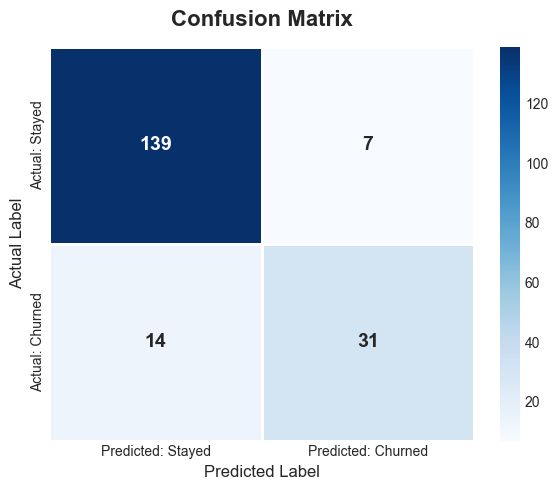

True Negatives  (correctly identified as Stayed)  : 139
False Positives (Stayed but predicted as Churned) : 7
False Negatives (Churned but predicted as Stayed) : 14
True Positives  (correctly identified as Churned) : 31


In [15]:


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'],
            linewidths=1, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly identified as Stayed)  : {tn}")
print(f"False Positives (Stayed but predicted as Churned) : {fp}")
print(f"False Negatives (Churned but predicted as Stayed) : {fn}")
print(f"True Positives  (correctly identified as Churned) : {tp}")

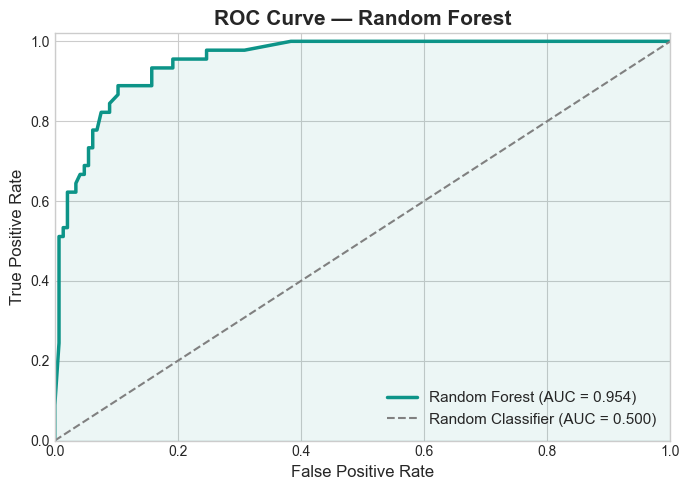

AUC Score: 0.9537  (closer to 1.0 is better)


In [16]:


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#0D9488', lw=2.5, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#0D9488')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {auc:.4f}  (closer to 1.0 is better)")

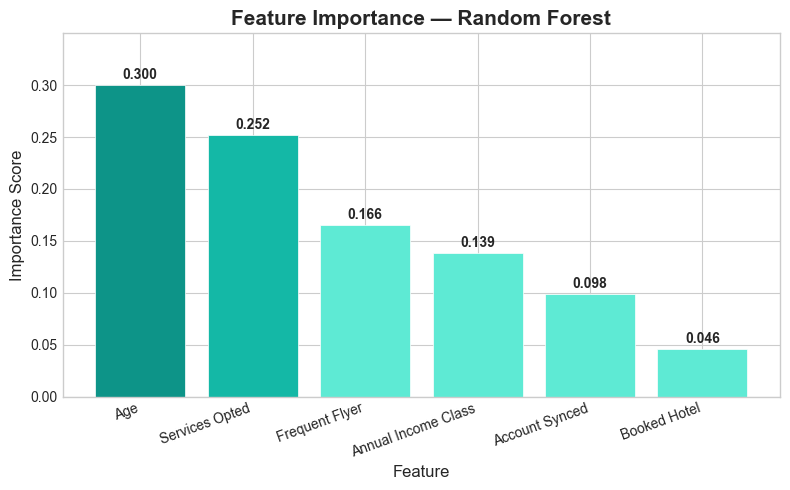


Feature Importances (ranked):
  Age                       : 0.3000
  Services Opted            : 0.2516
  Frequent Flyer            : 0.1655
  Annual Income Class       : 0.1385
  Account Synced            : 0.0984
  Booked Hotel              : 0.0460


In [17]:


feature_names = ['Age', 'Frequent Flyer', 'Annual Income Class',
                 'Services Opted', 'Account Synced', 'Booked Hotel']
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#0D9488' if i == 0 else '#14B8A6' if i == 1 else '#5EEAD4'
          for i in range(len(feature_names))]
bars = ax.bar([feature_names[i] for i in sorted_idx],
              [importances[i] for i in sorted_idx],
              color=colors, edgecolor='white', linewidth=0.5)


for bar, val in zip(bars, [importances[i] for i in sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Feature Importance — Random Forest', fontsize=15, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Importance Score', fontsize=12)
ax.set_ylim(0, max(importances) + 0.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importances (ranked):")
for i in sorted_idx:
    print(f"  {feature_names[i]:<25} : {importances[i]:.4f}")

---
## 7. Visualizations

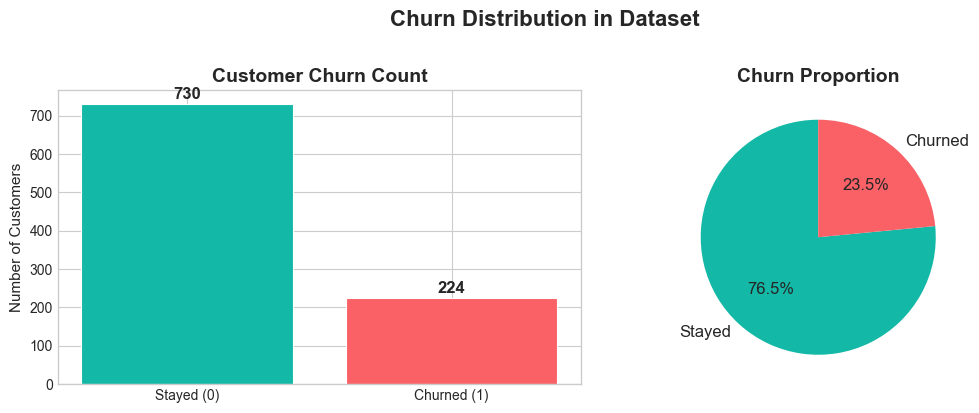

In [18]:


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

churn_counts = df['Target'].value_counts()
axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
            color=['#14B8A6', '#F96167'], edgecolor='white', linewidth=0.8)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers', fontsize=11)


axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['#14B8A6', '#F96167'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Churn Distribution in Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

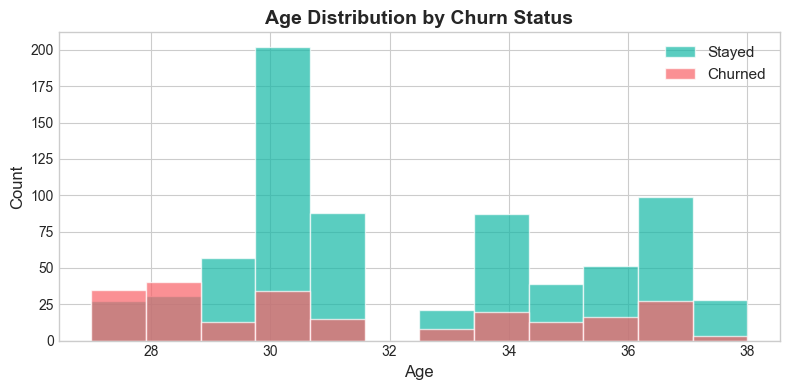

In [19]:

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, '#14B8A6', 'Stayed'), (1, '#F96167', 'Churned')]:
    ax.hist(df[df['Target'] == label]['Age'], bins=12, alpha=0.7,
            color=color, label=name, edgecolor='white')
ax.set_title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

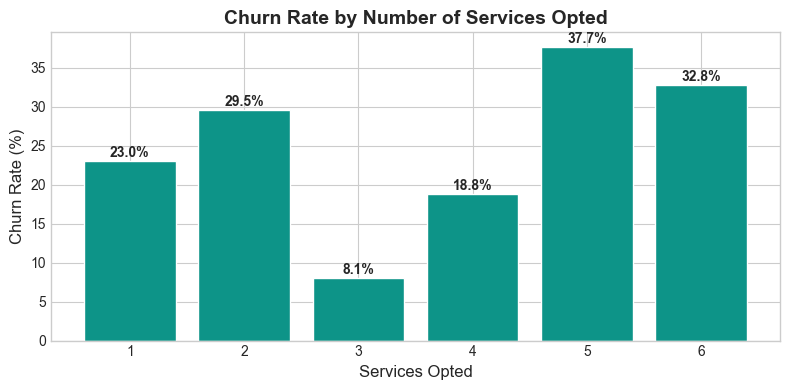

In [20]:

fig, ax = plt.subplots(figsize=(8, 4))
churn_by_services = df.groupby('ServicesOpted')['Target'].mean() * 100
ax.bar(churn_by_services.index, churn_by_services.values,
       color='#0D9488', edgecolor='white')
for x, y in zip(churn_by_services.index, churn_by_services.values):
    ax.text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Number of Services Opted', fontsize=14, fontweight='bold')
ax.set_xlabel('Services Opted', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xticks(range(1, 7))
plt.tight_layout()
plt.savefig('services_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

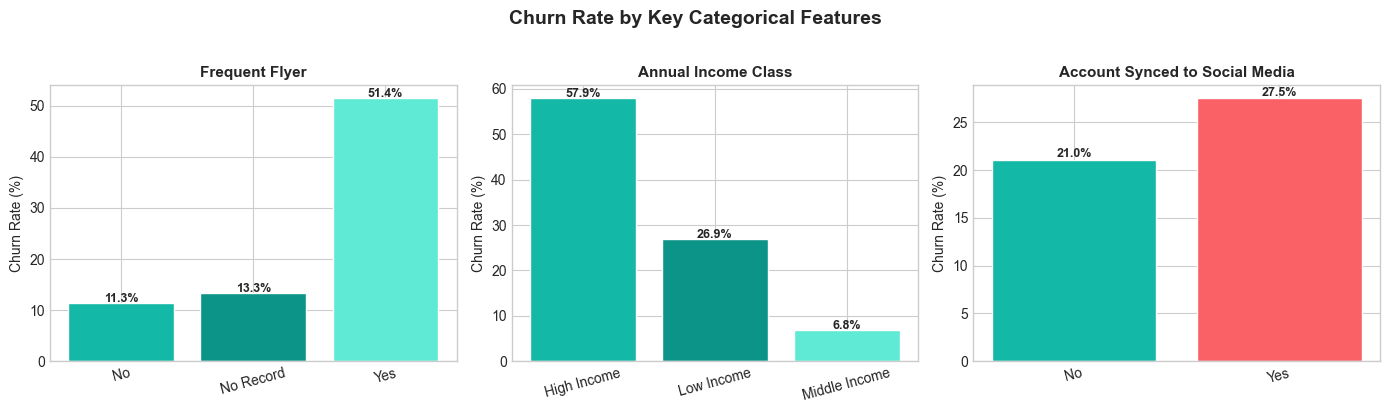

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cat_features = [
    ('FrequentFlyer', 'Frequent Flyer'),
    ('AnnualIncomeClass', 'Annual Income Class'),
    ('AccountSyncedToSocialMedia', 'Account Synced to Social Media')
]

colors_list = [['#14B8A6', '#0D9488', '#5EEAD4'],
               ['#14B8A6', '#0D9488', '#5EEAD4'],
               ['#14B8A6', '#F96167']]

for ax, (col, title), colors in zip(axes, cat_features, colors_list):
    churn_rate = df.groupby(col)['Target'].mean() * 100
    ax.bar(churn_rate.index, churn_rate.values, color=colors[:len(churn_rate)], edgecolor='white')
    for x, y in zip(range(len(churn_rate)), churn_rate.values):
        ax.text(x, y + 0.3, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

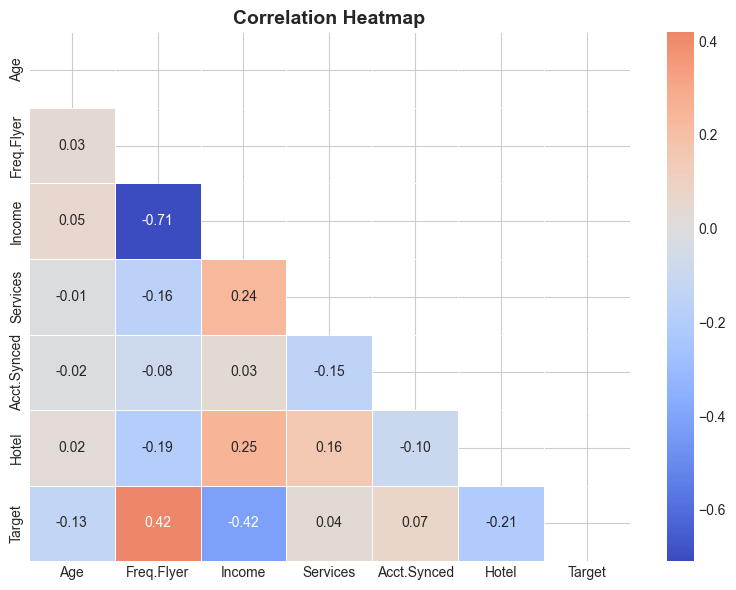

In [22]:


fig, ax = plt.subplots(figsize=(8, 6))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            xticklabels=['Age','Freq.Flyer','Income','Services','Acct.Synced','Hotel','Target'],
            yticklabels=['Age','Freq.Flyer','Income','Services','Acct.Synced','Hotel','Target'])
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusion

### Model Performance Summary
The Random Forest classifier achieved:
- **Accuracy: 89.01%** — nearly 9 in every 10 test customers were correctly classified
- **AUC Score: 0.9537** — excellent discriminating ability between churners and loyal customers
- **Precision (Churned): 82%** — when the model flags a customer as likely to churn, it is right 82% of the time
- **Recall (Churned): 69%** — the model successfully identifies 69% of all actual churners

### Key Features Contributing to Churn
Based on the feature importance analysis:
1. **Age (29.9%)** — the single most influential predictor; younger customers churn more frequently
2. **Services Opted (25.2%)** — customers who opted for fewer services are more likely to churn
3. **Frequent Flyer Status (16.6%)** — confirmed frequent flyers show different churn patterns
4. **Annual Income Class (13.9%)** — income bracket correlates with service loyalty
5. **Account Synced to Social Media (9.8%)** — digital engagement is a moderate predictor
6. **Booked Hotel or Not (4.6%)** — a weaker but still relevant feature

### Business Insights
- The overall churn rate in this dataset is ~23.5%, which is significant for the travel industry
- Younger customers who use fewer services are the highest-risk segment — targeted loyalty programmes and service bundle offers could retain them
- Customers with no frequent flyer record have a notably higher churn probability, suggesting that the airline should prioritise enrolling them in a loyalty programme early

### Possible Improvements and Future Enhancements
- **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to find optimal `n_estimators`, `max_depth`, and `min_samples_split` values
- **Class Imbalance Handling**: Apply SMOTE (Synthetic Minority Over-sampling Technique) to address the 76:24 class imbalance and improve recall for churners
- **Additional Algorithms**: Compare performance with XGBoost, LightGBM, or a voting ensemble
- **Richer Feature Engineering**: Add customer tenure, recency of last booking, total spend, and complaint history
- **Explainability**: Integrate SHAP (SHapley Additive exPlanations) for individual-level prediction explanations